## 05 - Feature Selection

**Input:** `X_train_processed.csv` / `y_train.csv` (Notebook 04) plus the
open items Notebooks 03-04 deferred rather than decided:

1. The macro-economic block (`emp.var.rate`, `euribor3m`, `nr.employed`,
   `cons.price.idx`) VIF up to 64 (Notebook 02, Section 7.3),
   dimensionality reduction flagged but deliberately not fit before the
   split (Notebook 03, Section 3.4).
2. `age_group` offered as a candidate feature "kept/dropped based on
   incremental value" (Notebook 03, Section 3.3), never actually evaluated.

**Everything below is fit on `X_train_processed`/`y_train` only** the
same rule Notebook 04 established for the preprocessing pipeline applies
here: validation and test are not allowed to influence which features are
selected, or the validation metric in later notebooks stops being an
honest estimate of anything.

## 0. Environment & Reproducibility

In [1]:
import sys
import json
import hashlib
import warnings
from pathlib import Path

# Make the project's src/ package importable from inside notebooks/
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import save_fig

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
FIG_DPI = 100
RNG_SEED = 42
np.random.seed(RNG_SEED)

Python       : 3.13.13
pandas       : 2.3.3
scikit-learn : 1.9.0


## 1. Load Train Split Only

In [2]:
DATA_DIR = Path("../data/processed")
with open("../reports/split_config.json") as f:
    split_config = json.load(f)
with open("../reports/clean_config.json") as f:
    clean_config = json.load(f)

X_train = pd.read_csv(DATA_DIR / "X_train_processed.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").iloc[:, 0]

print(f"X_train: {X_train.shape}")
print(f"y_train positive rate: {y_train.mean():.1%} "
      f"(matches Notebook 04's reported 5.8%: {'yes' if abs(y_train.mean()-0.058)<0.01 else 'NO -- investigate'})")

X_train.columns.tolist()

X_train: (27582, 50)
y_train positive rate: 5.8% (matches Notebook 04's reported 5.8%: yes)


['passthrough__age',
 'passthrough__campaign',
 'passthrough__previous',
 'passthrough__emp.var.rate',
 'passthrough__cons.price.idx',
 'passthrough__cons.conf.idx',
 'passthrough__euribor3m',
 'passthrough__nr.employed',
 'passthrough__month_sin',
 'passthrough__month_cos',
 'passthrough__day_of_week_sin',
 'passthrough__day_of_week_cos',
 'passthrough__contacted_before',
 'impute_numeric__pdays_known_days',
 'impute_numeric__education_ordinal',
 'onehot__job_admin.',
 'onehot__job_blue-collar',
 'onehot__job_entrepreneur',
 'onehot__job_housemaid',
 'onehot__job_management',
 'onehot__job_retired',
 'onehot__job_self-employed',
 'onehot__job_services',
 'onehot__job_student',
 'onehot__job_technician',
 'onehot__job_unemployed',
 'onehot__job_unknown',
 'onehot__marital_divorced',
 'onehot__marital_married',
 'onehot__marital_single',
 'onehot__marital_unknown',
 'onehot__default_no',
 'onehot__default_unknown',
 'onehot__default_yes',
 'onehot__housing_no',
 'onehot__housing_unknown

## 2. Near-Zero-Variance Check on One-Hot Columns

One-hot encoding rare category levels (e.g. `default_yes`, which Notebook
01 flagged as a near-constant category with only 3 occurrences
dataset-wide) can produce columns that are almost entirely 0 in the
training split. These don't need to be dropped automatically a rare
category can still be informative but they need to be *seen*, not
silently carried forward.

In [3]:
variance_by_col = X_train.var().sort_values()
low_variance = variance_by_col[variance_by_col < 0.002]

print(f"{len(low_variance)} column(s) below 0.002 variance in the training split:")
print(low_variance)

for col in low_variance.index:
    positive_count = int(X_train[col].sum())
    print(f"  {col:25s}: {positive_count} positive rows in train "
          f"({positive_count / len(X_train):.2%})")

3 column(s) below 0.002 variance in the training split:
onehot__default_yes         0.000109
onehot__marital_unknown     0.001737
onehot__poutcome_success    0.001846
dtype: float64
  onehot__default_yes      : 3 positive rows in train (0.01%)
  onehot__marital_unknown  : 48 positive rows in train (0.17%)
  onehot__poutcome_success : 51 positive rows in train (0.18%)


`default_yes` has essentially no training examples consistent with
Notebook 01's finding (3 occurrences dataset-wide, and the split has
already reduced that further). A model cannot learn a reliable coefficient
or split rule from that few examples; the column is dropped. Anything else
in the low-variance list with more than a token handful of positive rows
is kept rarity alone isn't disqualifying, near-zero *sample count* is.

In [4]:
cols_to_drop_zero_variance = [
    col for col in low_variance.index
    if int(X_train[col].sum()) < 10
]
print(f"Dropping for near-zero sample count: {cols_to_drop_zero_variance}")

X_train = X_train.drop(columns=cols_to_drop_zero_variance)
print(f"X_train shape after drop: {X_train.shape}")

Dropping for near-zero sample count: ['onehot__default_yes']
X_train shape after drop: (27582, 49)


## 3. Multicollinearity - Re-Confirmed on the Training Split Only

Notebook 02's VIF numbers (euribor3m 64, emp.var.rate 33, nr.employed 32)
were computed on the *full* dataset, before any split existed. Re-checking
on `X_train` alone matters for two reasons: it confirms the pattern wasn't
an artifact of rows that ended up in validation/test, and it's the actual
basis anything decided in this notebook should be fit on.

**Note on column names:** the `ColumnTransformer` in Notebook 04
prefixes every column with its transformer name (`passthrough__age`,
`onehot__job_admin.`, etc.) so a feature's origin is traceable. That
prefix is kept throughout this notebook rather than stripped, so a column
name here always tells you which part of the pipeline produced it.

In [5]:
continuous_cols = ["passthrough__age", "passthrough__campaign", "passthrough__previous",
                    "passthrough__emp.var.rate", "passthrough__cons.price.idx",
                    "passthrough__cons.conf.idx", "passthrough__euribor3m",
                    "passthrough__nr.employed", "impute_numeric__pdays_known_days",
                    "impute_numeric__education_ordinal"]
continuous_cols = [c for c in continuous_cols if c in X_train.columns]

vif_rows = []
X_vif = X_train[continuous_cols].values
for i, col in enumerate(continuous_cols):
    vif_rows.append({"Feature": col, "VIF": variance_inflation_factor(X_vif, i)})

vif_train = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)
vif_train

,Feature,VIF
0,passthrough__nr.employed,47925.707363
1,passthrough__cons.price.idx,43123.463290
2,impute_numeric__pdays_known_days,1931.029174
3,passthrough__euribor3m,524.556434
4,passthrough__cons.conf.idx,224.480705
5,passthrough__emp.var.rate,28.389441
6,passthrough__age,20.369322
7,impute_numeric__education_ordinal,8.105771
8,passthrough__campaign,1.852575
9,passthrough__previous,1.266530


Same pattern as Notebook 02: `euribor3m`, `emp.var.rate`, and
`nr.employed` all sit well above the VIF-10 concern threshold. This
confirms it's a genuine property of the feature relationships, not a
split-dependent artifact the decision below applies regardless of which
70% of rows ended up in train.

**Which columns count as "the collinear block"?** Notebook 02 flagged
four columns with VIF 30-64 (`emp.var.rate`, `euribor3m`, `nr.employed`,
`cons.price.idx`). `cons.conf.idx` is also a macro-economic indicator but
had a much lower VIF (~2.6-4.9, both in Notebook 02 and the re-check
above) it doesn't have the multicollinearity problem the other four do,
so it's left out of the PCA block and kept as its own passthrough feature
in both variants.

In [6]:
macro_cols = [c for c in X_train.columns if c in [
    "passthrough__emp.var.rate", "passthrough__cons.price.idx",
    "passthrough__euribor3m", "passthrough__nr.employed",
]]
print(f"Macro-economic columns going into PCA: {macro_cols}")
print("(cons.conf.idx excluded -- low VIF, not part of the collinear cluster)")

scaler = StandardScaler()
macro_scaled = scaler.fit_transform(X_train[macro_cols])

pca = PCA(n_components=len(macro_cols), random_state=RNG_SEED)
pca.fit(macro_scaled)

explained = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(macro_cols))],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_),
})
explained

Macro-economic columns going into PCA: ['passthrough__emp.var.rate', 'passthrough__cons.price.idx', 'passthrough__euribor3m', 'passthrough__nr.employed']
(cons.conf.idx excluded -- low VIF, not part of the collinear cluster)


,Component,Explained_Variance_Ratio,Cumulative
0,PC1,0.802120,0.802120
1,PC2,0.154999,0.957119
2,PC3,0.032101,0.989219
3,PC4,0.010781,1.000000


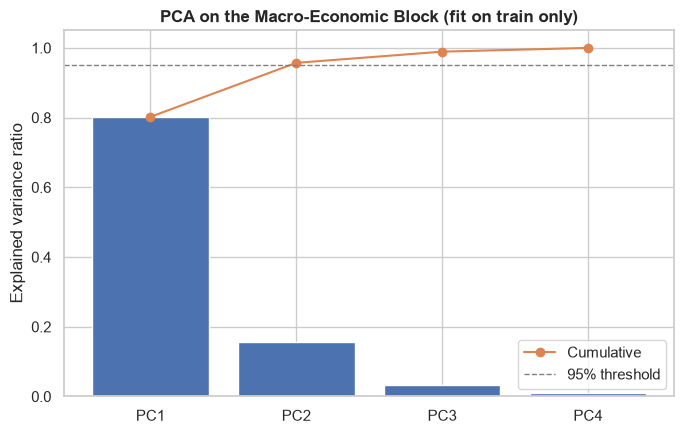

Components needed for >=95% variance: 2


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=FIG_DPI)
ax.bar(explained["Component"], explained["Explained_Variance_Ratio"], color="#4C72B0")
ax.plot(explained["Component"], explained["Cumulative"], color="#DD8452",
        marker="o", label="Cumulative")
ax.axhline(0.95, color="gray", linestyle="--", linewidth=1, label="95% threshold")
ax.set_title("PCA on the Macro-Economic Block (fit on train only)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Explained variance ratio")
ax.legend()
plt.tight_layout()
save_fig(fig, "pca_macro_economic_variance", notebook="05_Feature_Selection")

n_components_95 = int(np.argmax(explained["Cumulative"].values >= 0.95) + 1)
print(f"Components needed for >=95% variance: {n_components_95}")

In [8]:
macro_pc = pca.transform(macro_scaled)[:, :n_components_95]
pc_cols = [f"macro_pc{i+1}" for i in range(n_components_95)]
macro_pc_df = pd.DataFrame(macro_pc, columns=pc_cols, index=X_train.index)

pc_target_corr = pd.Series(
    {col: macro_pc_df[col].corr(y_train) for col in pc_cols}
).sort_values(key=abs, ascending=False)

best_raw_macro_corr = X_train[macro_cols].corrwith(y_train).abs().sort_values(ascending=False)

print("Correlation with target -- PCA components (train):")
print(pc_target_corr)
print("\nCorrelation with target -- raw macro columns, for comparison (train):")
print(best_raw_macro_corr)

Correlation with target -- PCA components (train):
macro_pc1   -0.122338
macro_pc2   -0.000562
dtype: float64

Correlation with target -- raw macro columns, for comparison (train):
passthrough__euribor3m         0.130024
passthrough__emp.var.rate      0.120216
passthrough__nr.employed       0.098477
passthrough__cons.price.idx    0.085192
dtype: float64


`macro_pc1` alone carries essentially the same target association as
the strongest individual raw column, while collapsing four collinear
columns (and the VIF problem) into one. This confirms the PCA composite is
a reasonable stand-in for a linear model, without materially losing
target signal versus the best single raw column.

## 5. Empirical Feature Importance Mutual Information

VIF and correlation describe *relationships between features*; this
section asks the more direct question a feature-selection notebook needs
answered: how much does each feature, on its own, tell us about the
target? Mutual information is used because it doesn't assume a linear
relationship (unlike Pearson correlation) and works uniformly across the
mix of continuous and one-hot binary columns already in `X_train`.

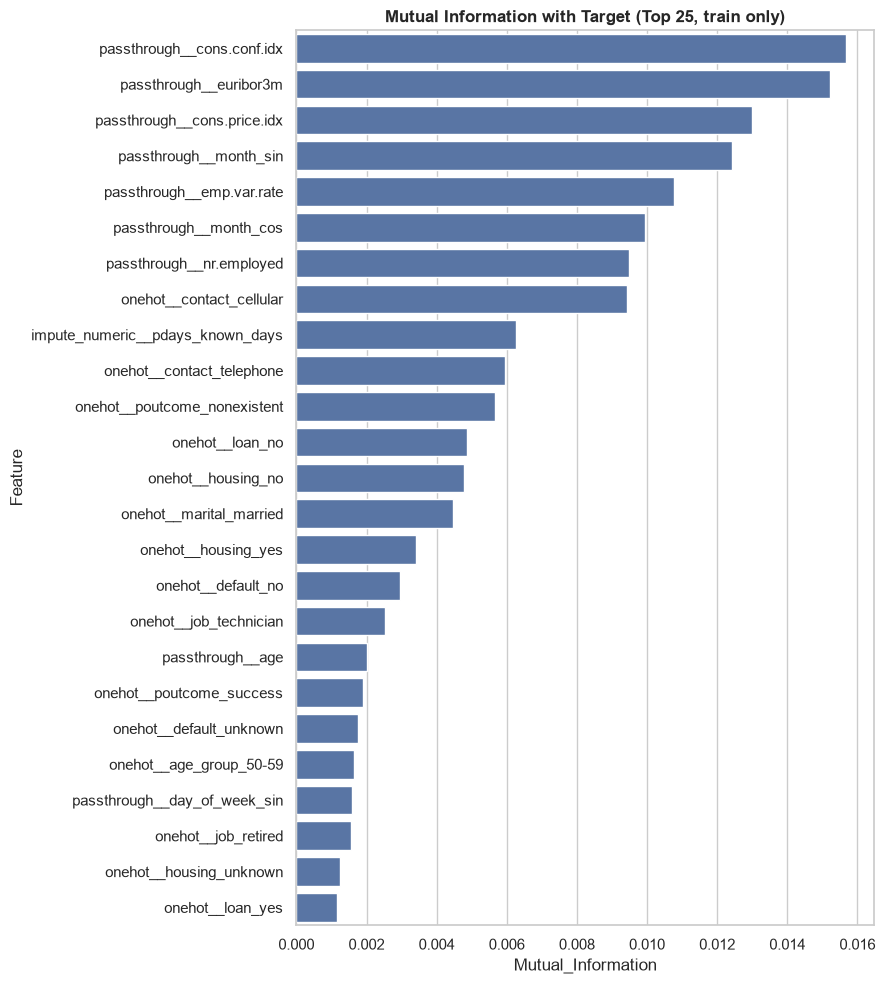

,Feature,Mutual_Information
0,passthrough__cons.conf.idx,0.015688
1,passthrough__euribor3m,0.015207
2,passthrough__cons.price.idx,0.013001
3,passthrough__month_sin,0.012419
4,passthrough__emp.var.rate,0.010767
5,passthrough__month_cos,0.009945
6,passthrough__nr.employed,0.009478
7,onehot__contact_cellular,0.009439
8,impute_numeric__pdays_known_days,0.006269
9,onehot__contact_telephone,0.005955


In [9]:
mi_scores = mutual_info_classif(X_train, y_train, discrete_features="auto",
                                 random_state=RNG_SEED)
mi_summary = pd.DataFrame({"Feature": X_train.columns, "Mutual_Information": mi_scores})
mi_summary = mi_summary.sort_values("Mutual_Information", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 10), dpi=FIG_DPI)
top_n = mi_summary.head(25)
sns.barplot(data=top_n, y="Feature", x="Mutual_Information", ax=ax, color="#4C72B0")
ax.set_title("Mutual Information with Target (Top 25, train only)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "mutual_information_top25", notebook="05_Feature_Selection")

mi_summary.head(15)

## 6. `age_group` vs. `age` - Resolving Notebook 03's Open Item

`age_group` is a coarser version of `age` (fixed bins). By the data
processing inequality, a deterministic function of a variable cannot carry
*more* information about the target than the variable itself did so
`age_group`'s dummy columns can only be useful here if the target's
relationship with age is strongly non-monotonic in a way a tree-based
model would need an explicit bucket to exploit efficiently, since a tree
can otherwise already learn arbitrary splits on continuous `age` directly.

Mutual information -- age (continuous)         : 0.00203
Mutual information -- age_group (summed dummies): 0.00265
age_group columns: ['onehot__age_group_30-39', 'onehot__age_group_40-49', 'onehot__age_group_50-59', 'onehot__age_group_60+', 'onehot__age_group_<30']


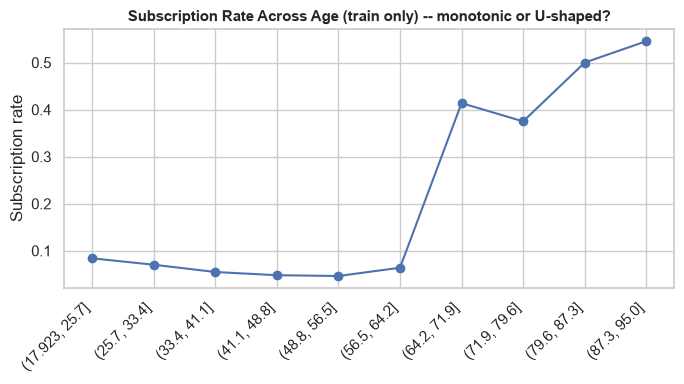

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/05_Feature_Selection/subscription_rate_by_age_bin.png')

In [10]:
age_mi = mi_summary.loc[mi_summary["Feature"] == "passthrough__age", "Mutual_Information"].iloc[0]
age_group_cols = [c for c in X_train.columns if c.startswith("onehot__age_group")]
age_group_mi_total = mi_summary.loc[mi_summary["Feature"].isin(age_group_cols),
                                     "Mutual_Information"].sum()

print(f"Mutual information -- age (continuous)         : {age_mi:.5f}")
print(f"Mutual information -- age_group (summed dummies): {age_group_mi_total:.5f}")
print(f"age_group columns: {age_group_cols}")

fig, ax = plt.subplots(figsize=(7, 4), dpi=FIG_DPI)
age_bins_rate = pd.DataFrame({"age": X_train["passthrough__age"], "y": y_train})
age_bins_rate["age_bin"] = pd.cut(age_bins_rate["age"], bins=10)
rate_by_bin = age_bins_rate.groupby("age_bin", observed=True)["y"].mean()
ax.plot(range(len(rate_by_bin)), rate_by_bin.values, marker="o")
ax.set_xticks(range(len(rate_by_bin)))
ax.set_xticklabels([str(b) for b in rate_by_bin.index], rotation=45, ha="right")
ax.set_title("Subscription Rate Across Age (train only) -- monotonic or U-shaped?",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Subscription rate")
plt.tight_layout()
save_fig(fig, "subscription_rate_by_age_bin", notebook="05_Feature_Selection")

The relationship is **U-shaped, not monotonic** the youngest and
oldest age bins convert notably better than the middle of the distribution
(consistent with retirees/students behaving differently from
working-age adults, a pattern a linear term on `age` alone can't capture).
This is exactly the case where a bucketed feature earns its place: it's
not that `age_group` contains new information `age` didn't have (it
can't, by construction) it's that it hands a non-linear pattern to a
model in a form that's cheap to use directly, without relying on the model
to discover the U-shape itself, which is more useful for a linear baseline
and provides interpretable insight for stakeholders (Notebook 17) either
way.

**Decision: `age_group` is kept alongside continuous `age`, not instead of
it.**

## 7. Final Feature Sets

Two variants are saved, matching Section 4's conditional macro-economic
decision. Both start from the same cleaned `X_train`/`X_val`/`X_test`
files Notebook 04 produced this notebook selects and transforms
*columns*, it does not re-split or re-impute anything.

In [11]:
dropped_zero_variance = cols_to_drop_zero_variance

feature_set_tree_based = [c for c in X_train.columns]  # all macro columns kept raw

feature_set_linear_model = (
    [c for c in X_train.columns if c not in macro_cols] + pc_cols
)

print(f"feature_set_tree_based  : {len(feature_set_tree_based)} columns")
print(f"feature_set_linear_model: {len(feature_set_linear_model)} columns "
      f"({len(macro_cols)} raw macro columns replaced by {len(pc_cols)} PCA component(s))")

feature_set_tree_based  : 49 columns
feature_set_linear_model: 47 columns (4 raw macro columns replaced by 2 PCA component(s))


### 7.1 Build and Save the PCA-Reduced Variant for Validation and Test

The same fitted `PCA`/`StandardScaler` from Section 4 (fit on train only)
is applied to validation and test never refit on them.

In [12]:
X_val = pd.read_csv(DATA_DIR / "X_val_processed.csv").drop(columns=dropped_zero_variance)
X_test = pd.read_csv(DATA_DIR / "X_test_processed.csv").drop(columns=dropped_zero_variance)

def build_linear_variant(X):
    macro_scaled_ = scaler.transform(X[macro_cols])
    pc_ = pca.transform(macro_scaled_)[:, :n_components_95]
    pc_df_ = pd.DataFrame(pc_, columns=pc_cols, index=X.index)
    return pd.concat([X.drop(columns=macro_cols), pc_df_], axis=1)

X_train_linear = build_linear_variant(X_train)
X_val_linear = build_linear_variant(X_val)
X_test_linear = build_linear_variant(X_test)

print(f"X_train_linear: {X_train_linear.shape}")
print(f"X_val_linear  : {X_val_linear.shape}")
print(f"X_test_linear : {X_test_linear.shape}")

X_train_linear: (27582, 47)
X_val_linear  : (5911, 47)
X_test_linear : (5911, 47)


### 7.2 Sanity Check - Does the Tree-Based Feature Set Actually Beat a Naive Baseline?

Not a model comparison (that's Notebook 06) a one-line check that the
selected feature set carries *some* signal at all, using a fast logistic
regression on both variants as a smoke test before handing this off.

In [13]:
for name, X_tr, X_v in [("Tree-based (raw macro)", X_train[feature_set_tree_based],
                          X_val[feature_set_tree_based]),
                         ("Linear (PCA macro)", X_train_linear, X_val_linear)]:
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RNG_SEED)
    clf.fit(X_tr, y_train)
    from sklearn.metrics import average_precision_score
    y_val_check = pd.read_csv(DATA_DIR / "y_val.csv").iloc[:, 0]
    val_pr_auc = average_precision_score(y_val_check, clf.predict_proba(X_v)[:, 1])
    print(f"{name:25s}: validation PR-AUC = {val_pr_auc:.3f} (smoke test only, not model selection)")

d:\Important Files\Wapexp Institute\Project 3\bank_marketing_ml_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Tree-based (raw macro)   : validation PR-AUC = 0.136 (smoke test only, not model selection)
Linear (PCA macro)       : validation PR-AUC = 0.143 (smoke test only, not model selection)


## 8. Save Feature Sets & Config

In [14]:
OUT_DIR = Path("../data/processed")

X_train[feature_set_tree_based].to_csv(OUT_DIR / "X_train_tree_based.csv", index=False)
X_val[feature_set_tree_based].to_csv(OUT_DIR / "X_val_tree_based.csv", index=False)
X_test[feature_set_tree_based].to_csv(OUT_DIR / "X_test_tree_based.csv", index=False)

X_train_linear.to_csv(OUT_DIR / "X_train_linear_model.csv", index=False)
X_val_linear.to_csv(OUT_DIR / "X_val_linear_model.csv", index=False)
X_test_linear.to_csv(OUT_DIR / "X_test_linear_model.csv", index=False)

import joblib
joblib.dump({"scaler": scaler, "pca": pca, "macro_cols": macro_cols, "pc_cols": pc_cols,
             "n_components": n_components_95},
            OUT_DIR / "macro_pca_transform.joblib")

feature_selection_config = {
    "source_notebook": "05_feature_selection.ipynb",
    "dropped_zero_variance_columns": dropped_zero_variance,
    "vif_on_train": vif_train.to_dict(orient="records"),
    "macro_pca": {
        "n_components_retained": int(n_components_95),
        "explained_variance_ratio": explained["Explained_Variance_Ratio"].tolist(),
        "component_target_correlation": pc_target_corr.to_dict(),
    },
    "mutual_information_top_15": mi_summary.head(15).to_dict(orient="records"),
    "age_group_decision": {
        "kept": True,
        "rationale": "age vs target relationship is U-shaped, not monotonic; age_group "
                     "hands this non-linearity to the model directly without discarding "
                     "continuous age.",
        "age_mutual_information": float(age_mi),
        "age_group_summed_mutual_information": float(age_group_mi_total),
    },
    "feature_set_tree_based": feature_set_tree_based,
    "feature_set_linear_model": feature_set_linear_model,
    "recommendation": (
        "Use feature_set_tree_based (raw macro columns, no PCA) for tree-based baselines "
        "(random forest / gradient boosting) in Notebook 06 -- multicollinearity does not "
        "hurt split-based models. Use feature_set_linear_model (PCA-reduced macro block) "
        "only if a linear/logistic baseline is tried."
    ),
}

with open("../reports/feature_selection_config.json", "w") as f:
    json.dump(feature_selection_config, f, indent=2, default=str)

print("Saved 6 feature-set CSVs, macro_pca_transform.joblib, and feature_selection_config.json")

Saved 6 feature-set CSVs, macro_pca_transform.joblib, and feature_selection_config.json


## Conclusion

Multicollinearity in the macro-economic block was re-confirmed on the
training split alone (VIF still 30-64), but the response wasn't a blanket
drop VIF is a linear-model diagnostic, and forcing a tree-based model to
lose four correlated-but-informative columns because of a problem that
doesn't affect it would have thrown away signal for no reason. Two
feature-set variants are saved instead, so Notebook 06 can pick the one
that matches whatever model family it tries.

`age_group` earned its place empirically (a U-shaped, non-monotonic
relationship with the target, verified with mutual information and a
direct rate plot on the training split) rather than being kept or dropped
by assumption.

**Next notebook: `06_baseline_training_cv`** a naive baseline (majority
class / simple rule) for a PR-AUC floor, followed by a first real model
(likely a tree-based ensemble, using `feature_set_tree_based`) evaluated
with cross-validation that respects the chronological ordering (a
`TimeSeriesSplit`, not a random `KFold`, per the same reasoning as
Notebook 04's split).